# IMPORTING REQUIRED LIBRARIES

* numpy - The basic module for all our mathematical computing stuff - since the images are in the form of intensity matrix, matrix operations are done using this module
* matplotlib.pyplot - generally used to plot graphs, here mainly used to show the processed images
* os - module manipulating the operating system - here used to find folders based on file path and also list them and access them
* cv2 - OpenCV - module for computer vision - used to read images into the matrix format that the computer can understand and do its work on
* sklearn.preprocessing - a module from the Scikit-learn library (just like pyplot is a module in the matplotlib library, hence matplotlib.pyplot) - used for the LabelEncoder for the labels
* tensorflow.keras.models - TensorFlow is an open-source ML platform developed by google - Keras being TensorFlow’s official high-level model for this purpose, i.e., it has a human-friendly code, hence high-level - models being a sub-module in Keras - used for Sequential to setup the layered “sequential” CNN model for the task
* tensorflow.keras.layers - another sub-module used to define the layers involved - we set up the “box” using the “models” and the contents using the “layers”
* tensorflow.keras.utils - another sub-module used for “to_categorical” to encode the types of emotions involved in form of “binary” arrays - for eg, happy = [1.0, 0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0], sad = [0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0], etc.
* tensorflow.keras.preprocessing.image - another sub-module for, as the name suggests, for preprocessing images - used in “data augmentation” with help of ImageDataGenerator


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-19 05:52:34.780573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781848355.014560      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781848355.079459      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781848355.625944      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781848355.625988      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781848355.625991      24 computation_placer.cc:177] computation placer alr

# THE CATEGORIES OF FACE EXPRESSIONS

We make the file path by copying the main directory's file path from the input window, and adding the required additional file paths to extract the total file path. This is because we were unable to copy the whole file path of the train and validation directly.

In [2]:
BASE_DIR = '/kaggle/input/datasets/jonathanoheix/face-expression-recognition-dataset/'
TRAIN_DIR  = os.path.join(BASE_DIR, 'images',  'train')
TEST_DIR  = os.path.join(BASE_DIR, 'images',  'validation')
CLASSES = sorted(os.listdir(TRAIN_DIR))
print(CLASSES) # make file path, access it and print the classes involved in sorted way

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


We print the classes available (in a sorted dictionary type of way) to cross check whether every class is included or not.

Now, we would like to see an example under each category. So, we kinda "plot" it. There are 7 sub-categories. We would like to see each of them. So plotting them in a 2x4 matrix suits, with one of the box empty. The rest of the code remains similar to Tanmay's. We basically show the first picture in our input directory under each category under train.

We set up our plotting plane -> for each class, access the first pic -> convert bgr to rgb format because apparently that's how it is saved, and we will get wrong colors -> show the image along with the respective class -> turn off the axis because it's not a graph we are plotting -> remove the last 8th plot box -> show the final grid of pics.

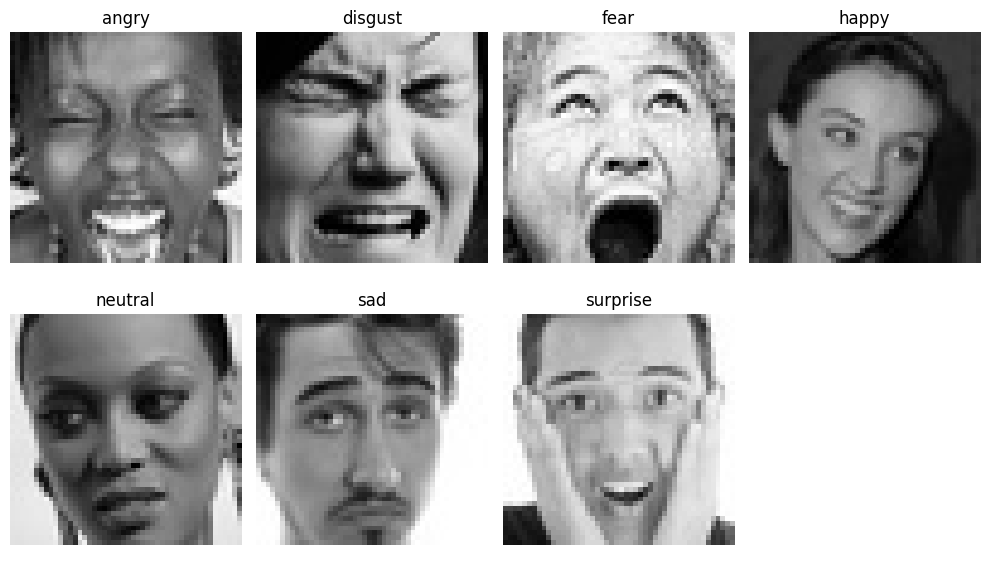

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for ax, cls in zip(axes.flat, CLASSES):
    img_path = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    img = cv2.imread(img_path) # access the 1st picture under each class
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR -> RGB
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show() # show the pictures in the 2x4 matrix, which comes out to be greyscaled

# LOAD & RESIZE IMAGES and NORMALIZE & ENCODE LABELS

We see that the available images are in greyscale, i.e., there is only 1 parameter involved, and not 3 like the RGB ones. So, we remove the RGB stuff used in the original code, and use 1 parameter.

We make a function which loads data from the directory. We initialize empty lists for the labels and their corresponding labels. We load the directory for each category, and use "IMREAD_GREYSCALE" to load the greyscale images and "read" them. We make the pic and the label arrays for our model to train on.

In [4]:
IMG_SIZE = 64 # the length & breadth of our converted image, read in greyscale to reduce number of parameters (3 -> 1)

def load_data(directory):
    images, labels = [], [] # image data and labels (class) list
    for cls in CLASSES:
        folder = os.path.join(directory, cls)
        for fname in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE) # read image in greyscale
            if img is None: continue # prevent code from crashing
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # resizing image
            images.append(img) # appending image data to images list
            labels.append(cls) # appending class data to labels list
    return np.array(images), np.array(labels)

X_train_raw, y_train_raw = load_data(TRAIN_DIR) # Train array (image + label)
X_test_raw,  y_test_raw  = load_data(TEST_DIR) # Test array (image + label)

X_train = np.expand_dims(X_train_raw, axis=-1) / 255.0 # expand_dims to (64,64) -> (64,64,1)
X_test  = np.expand_dims(X_test_raw, axis=-1) / 255.0 # and also, normalization as greyscale -> (0, 255)


le = LabelEncoder() # map distinct text categories to integers 0, 1, 2...
# "fit" acheives mapping, "transform" achieves the conversion, to_categorical for integer -> binary list
y_train = to_categorical(le.fit_transform(y_train_raw)) # int 3 -> bin list [0.0,0.0,1.0,0.0,0.0,0.0,0.0]
y_test  = to_categorical(le.transform(y_test_raw)) # just transform as we want to keep the same encoding

print("Classes:", le.classes_) # print the classes involved
print("X_train:", X_train.shape, "| y_train:", y_train.shape) # (no. of images, 64, 64, 1) 
print("X_test:",  X_test.shape,  "| y_test:",  y_test.shape) # (no. of images, 7) (7 - no. of classes)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
X_train: (28821, 64, 64, 1) | y_train: (28821, 7)
X_test: (7066, 64, 64, 1) | y_test: (7066, 7)


# BUILDING THE CNN

We need to keep in mind the fact that we used greyscale and not RGB. So, input_shape is (64, 64, 1) instead of (64, 64, 3). 

### The Blocks
* We use a total of 3 blocks, each with an increasing number of neuron count (32 -> 64 -> 128 -> 256), so as to identify more complex features and their combinations and finally arrive at the correct conclusion, in the classification block
* Conv2D - the "scanner" sliding through the image to identify features, set as a 3x3 matrix
* BatchNormalization - a "stabilizer" - normalizing the processed data before passing it onto for further processing - mainly used to prevent snowballing of mathematical instabilities that might be generated with each processing
* MaxPooling2D - shrinks the image size by half - converts non-overlapping 2x2 matrix to a 1x1 matrix with the maximum value - mostly to remove repetitive pixels, keep prominent data, and reduce image size
* Dropout - randomly "turns off" a percentage of neurons (0.4 = 40% of neurons turned off, processing done with the remaining 60% neurons) - reduces dependency on some particular neurons and forces the network to avoid relying on a simple trick to do the guesswork - basically prevents overfitting and makes it better
* Activation='relu' - stands for Rectified Linear Unit - turns any -ve values to 0, keeps the +ve as it is - removes useless background noise generating the -ve value after processing and keeps the focus on the main features like eyebrows and lips
* Padding='same' - while passing the 3x3 scanner matrix, and returning a single value, ideally what should happen is that (m) x (n) -> (m-2) x (n-2) matrix - to prevent this shrinkage, we keep a "ghost" border such that it's initially (m+2) x (n+2) and finally it is (m) x (n) matrix - the size is retained

### The Final Block
* The classification block to arrive at the final conclusion - it processes the outputs given by the layers, the features that has been found, and combines these findings to output what the model thinks about the image, whether 80% happy or 15% sad or 5% angry, and so on
* Flatten - the data is a 3D image map, so to squish it into an 1d array which the neural network can process and give the final verdict
* Dense(256) - penultimate layer with 256 neurons analyzing the features and their corresponding values and returning the final verdict based on the combinations
* Dense(len(CLASSES), activation='softmax') - final output layer - outputs a list of 7 percentage probabilities (one for each of the emotions) - the emotion with the highest percentage is the model's official prediction - the softmax function ensures that the returned probability value is between 0 to 1.

In [5]:
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)), # Block 1
    # 32, 64, 128, 256 = no. of different visual features (like edges or lines) the layer searches for - increases after each block
    # input_shape -> (64, 64, 1) & (3, 3) = the pixel size of the small sliding window used to scan the image
    # activation='relu' -> keeps positive structural features and throws away useless negative values (turns them to 0).
    # padding ='same' -> adds a ghost border around the image so the edges don't shrink during the scan -> mxn remains mxn matrix.
    BatchNormalization(), # "normalizes" the scaled-up data back, so that it doesn't cause processsing problem in the next blocks 
    MaxPooling2D(2,2), # converts (2n)x(2n) to nxn matrix by taking non-overlapping 2x2 matrices and replacing with the max value

    Conv2D(64, (3, 3), activation='relu', padding='same'), # Block 2
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu', padding='same'), # Block 3
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Final Classification Block
    Flatten(), # convert the complex 3d image map to a simple 1d array so that the neural network can read it
    Dense(256, activation='relu'), # increase neurons to prevents any potential blocks in image processing
    Dropout(0.4), # turns off 40% of the neurons -> break dependency on specific neurons -> reduce overfitting risk (apparently it's highest here)
    Dense(len(CLASSES), activation='softmax') # output 7 probabilities for each emotion, highest -> output; softmax -> keep values in [0,1] range
])

model.summary() # Provides a text-based blueprint of the neural network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781848497.663628      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781848497.670011      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,775 (8.36 MB)

 Trainable params: 2,192,327 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

# DATA AUGMENTATION

Used to modify data and prevent overfitting by manipulating the training dataset slightly.

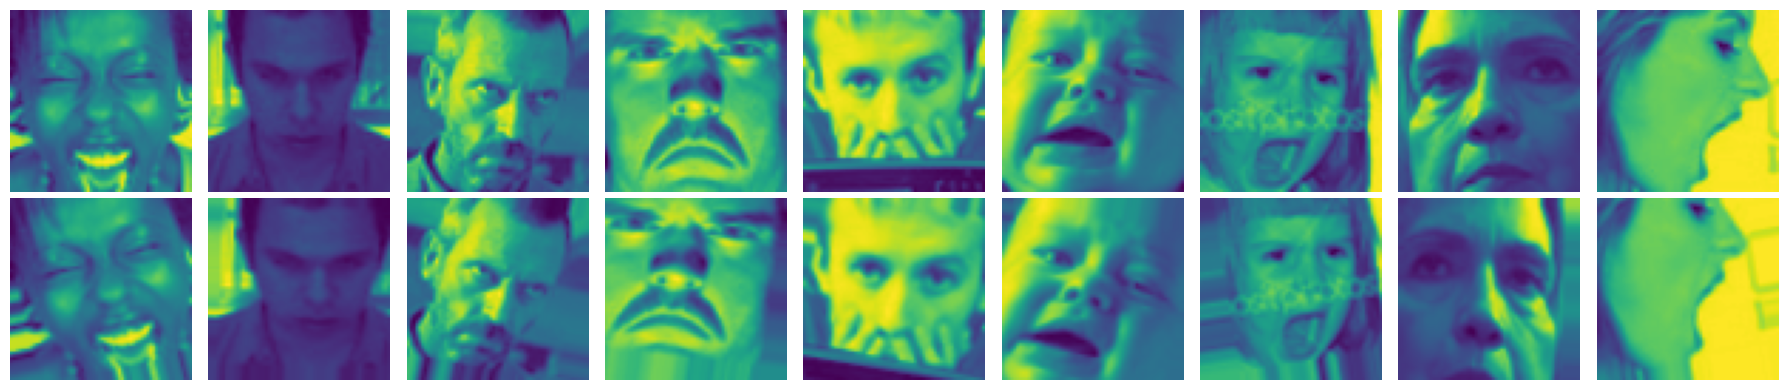

In [6]:
datagen = ImageDataGenerator(
    rotation_range=15, # randomly tilts the face up to 15 degrees left or right
    width_shift_range=0.1,
    height_shift_range=0.1, # shifts the face slightly off-center (up to 10% horizontally or vertically)
    horizontal_flip=True, # randomly mirrors the image horizontally
    zoom_range=0.1 # randomly zooms in or out by up to 10%
)

sample_batch = X_train[:9] # grabs the first 9 original images from your training set
aug_iter = datagen.flow(sample_batch, batch_size=9, shuffle=False) # passes the 9 images; shuffle=False to prevent mismatch of picture & corresponding labels
aug_batch = next(aug_iter) # gather the image info from the aug_iter iterable created

fig, axes = plt.subplots(2, 9, figsize=(18, 4)) 
for i in range(9):
    axes[0, i].imshow(sample_batch[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(aug_batch[i], 0, 1))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Augmented", fontsize=10)
plt.tight_layout()
plt.show()

# COMPILATION & TRAINING

This block handles the actual training of the model - how long to train, the adjustments to be done, the reward system, accuracy, training & validation.

`model.compile` (how to process data)
* optimizer='adam' - after every batch of images, it calculates how far off the model's guesses were and tweaks the internal settings (weights) just the right amount so the model does better next time
* loss='categorical_crossentropy' - kind of like a grading system - if the model predicts wrong, it gives a massize penalty or loss - the model will try to minimize this loss
* metrics=['accuracy'] - prints out accuracy during after each round or epoch

`model.fit` (what data to process and for how many times)
* datagen.flow(X_train, y_train, batch_size=64) - feeds your training data to the model in random sets of 64 images at a time
* epochs=20 - total number of rounds through the entire dataset
* validation_data=(X_test, y_test) - at the end of every epoch, the model verifies using the validation images to check how much it has learnt

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=35, # increased epoch number from 20 to 35 for better result, but risk of overfitting
    validation_data=(X_test, y_test)
)

Epoch 1/35


I0000 00:00:1781848502.556142      73 service.cc:152] XLA service 0x15453500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781848502.556183      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781848502.556187      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781848503.115696      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  6/451 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.1609 - loss: 6.0555

I0000 00:00:1781848507.507935      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


451/451 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.2496 - loss: 1.9230 - val_accuracy: 0.2709 - val_loss: 1.7618
Epoch 2/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.2889 - loss: 1.7193 - val_accuracy: 0.3624 - val_loss: 1.5950
Epoch 3/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3239 - loss: 1.6557 - val_accuracy: 0.3777 - val_loss: 1.5929
Epoch 4/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3541 - loss: 1.5933 - val_accuracy: 0.3663 - val_loss: 1.5371
Epoch 5/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3764 - loss: 1.5482 - val_accuracy: 0.4563 - val_loss: 1.4501
Epoch 6/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3843 - loss: 1.5207 - val_accuracy: 0.3960 - val_loss: 1.6101
Epoch 7/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.4032 - loss: 1.4978 - val_accuracy: 0.4677 - val_loss: 1.3387
Epoch 8/35
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.4238 - loss: 1.4625 - val_accurac

# TRAINING CURVES

* Plots training vs. validation metrics side-by-side after training finishes.
* Left Plot (axes[0]): Tracks accuracy improvement (higher is better).
* Right Plot (axes[1]): Tracks loss/error reduction (lower is better).
* Used to visually detect if the model is learning well or overfitting.

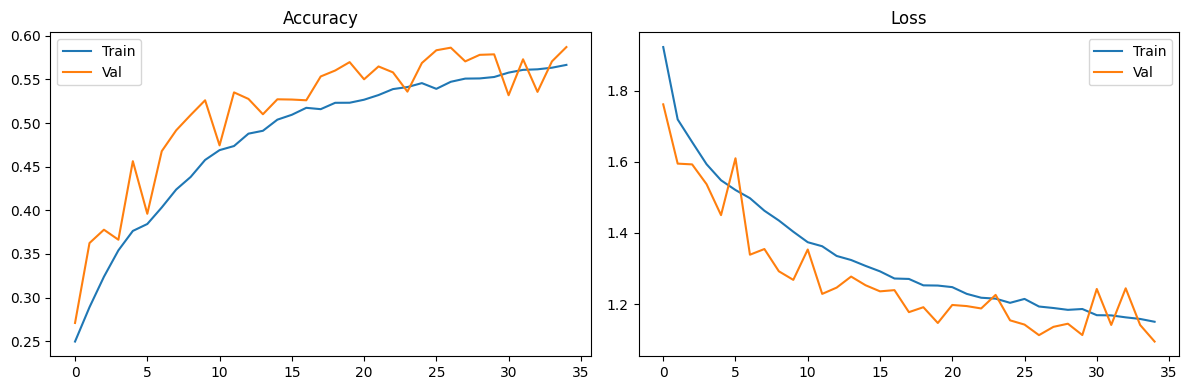

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train') # accuracy improvement plot
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train') # loss/error reduction plot
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show() # plots to see how well the model is learning

# CONFUSON (CONFUSION) MATRIX 

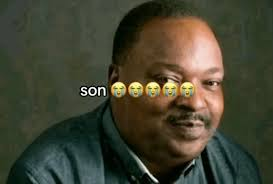

* Generates a 7x7 evaluation grid comparing true emotions against predicted emotions.
* Diagonal squares show correct predictions; off-diagonal squares reveal specific errors.
* Essential for seeing exactly which emotions the model mixes up (e.g., mistaking Fear for Surprise).


221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


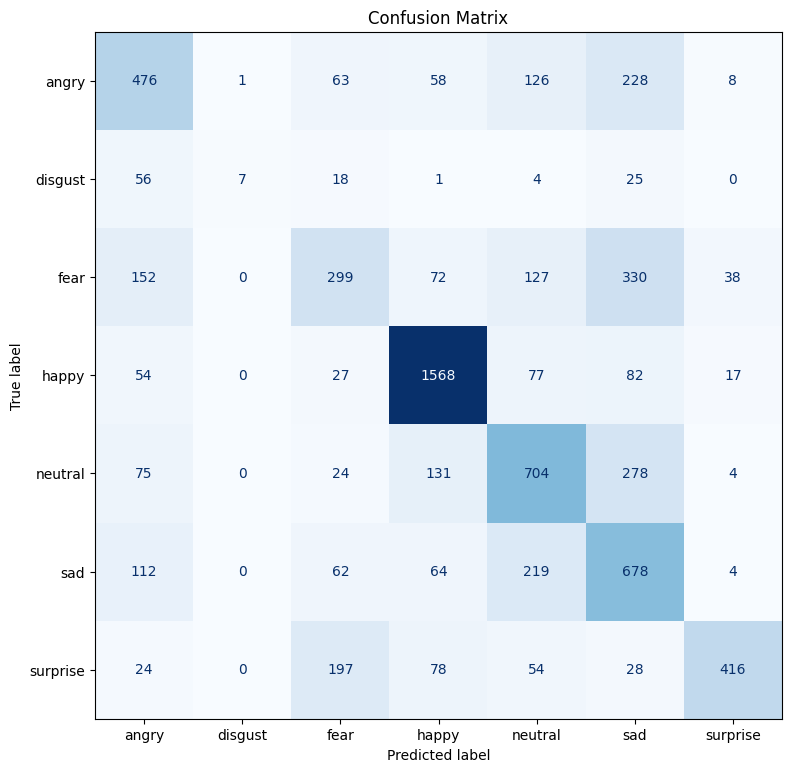

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test) # feeds the validation images to the trained model to get our probabilities
# looks at the 7 probabilities -> takes index of highest number -> convert back to their text names -> checks and stores if right or wrong
cm = confusion_matrix(y_test_raw, le.inverse_transform(np.argmax(y_pred, axis=1)))
# takes the data of 7x7 matrix above to make the confusion matrix; takes classes for the labelling stuff (le -> LabelEncoder used)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 8)) # 8x8 matrix -> lower-right 7x7 values & remaining labels (predicted & actual)
disp.plot(ax=ax, colorbar=False, cmap='Blues') # blue color theme; hides side scale bar; higher value = darker blue
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# PREDICTION ON 10 IMAGES

We feed 10 random images from the validation dataset. We set the plot space and loop through the chosen indices to obtain the image. We pass it through our trained model and obtain the deduced probabilities and output them in the format of a bar graph. 

```probs = model.predict(img[np.newaxis, ...], verbose=0)[0]```
* Why the [0]? It's because we are passing a list of 1 element. Apparently, Keras models are built to predict in a batch, but since we are giving only 1 image for processing at a time, we provide it with a list of a single element.
* Hence, it returns the output as a list of a single element, say -> [ [0.01, 0.02, 0.85, 0.02, 0.0, 0.10, 0.0] ]
* To access the only element, we do list[0]
* verbose=0 -> prevent cluttering outputs by turning off extra text outputs, eg, a seperate progress bar animation

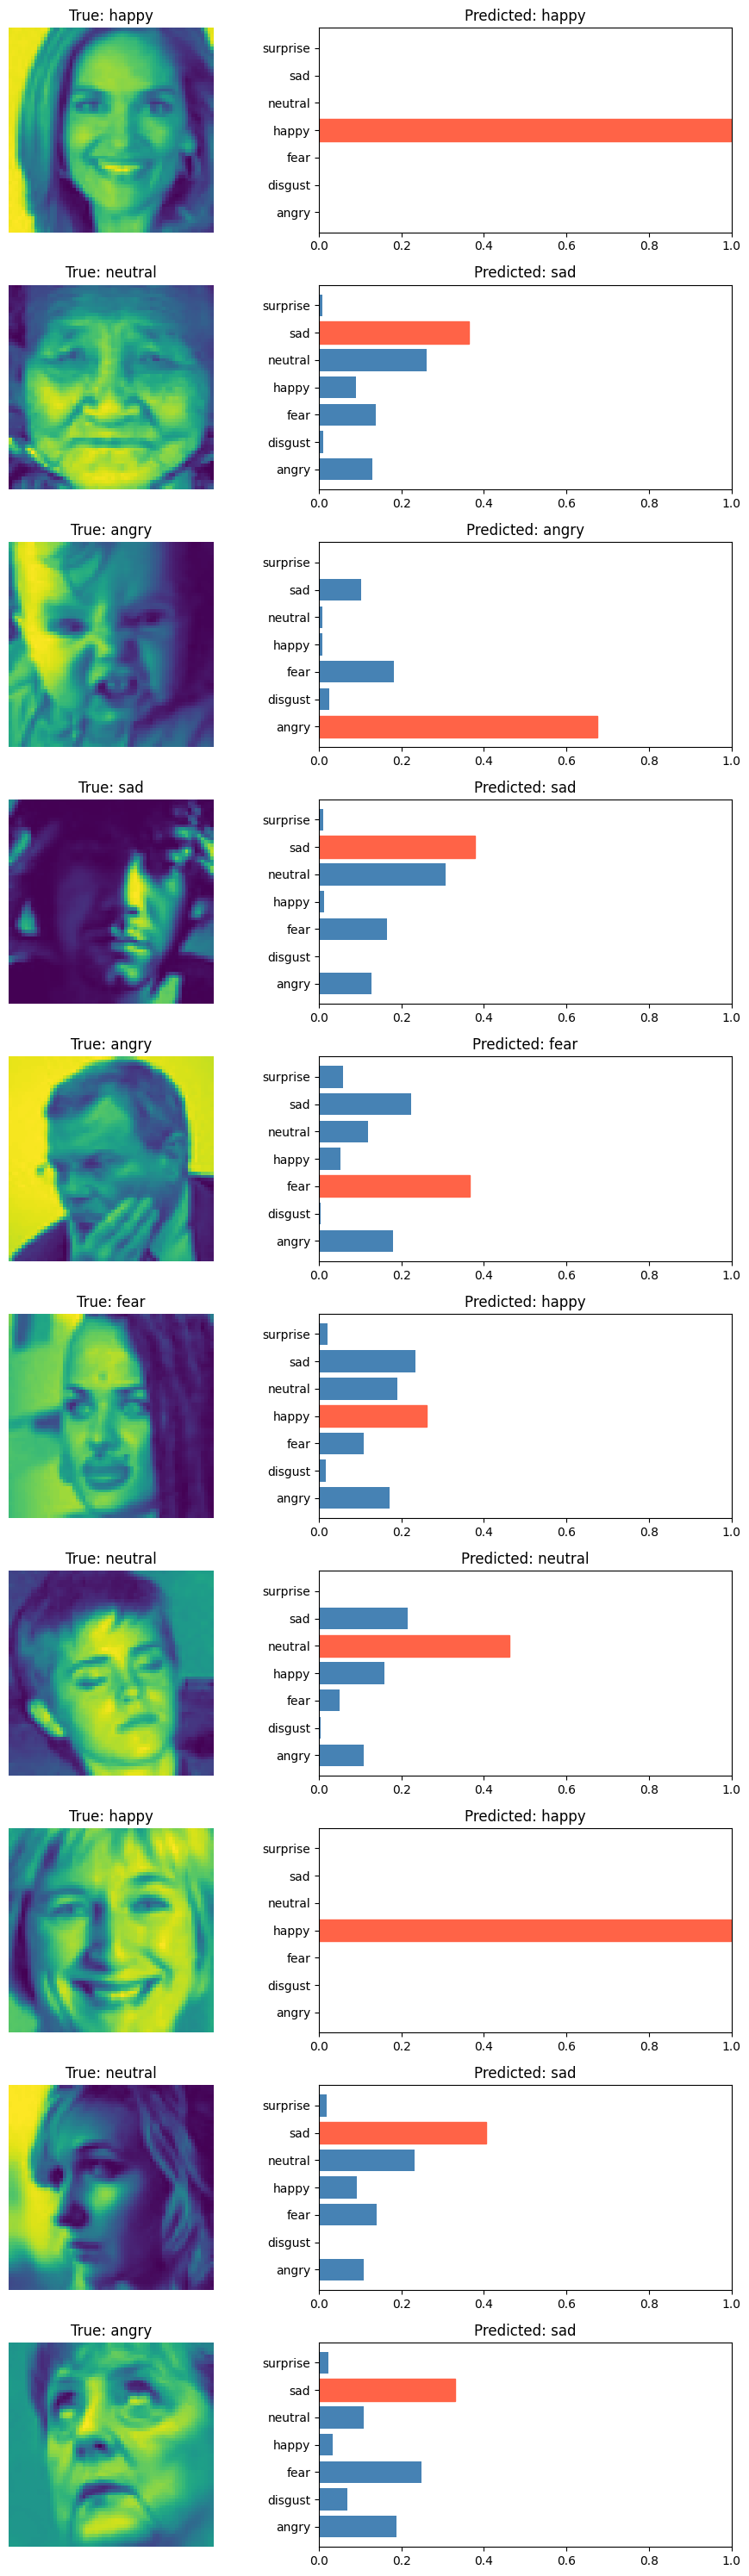

In [10]:
n = 10 # feeding 10 random images from validation dataset
indices = np.random.randint(len(X_test), size=n)

fig, axes = plt.subplots(n, 2, figsize=(10, n * 3)) # setup a vertical grid with 10 rows and 2 columns

for row, idx in enumerate(indices): # loop through each of the 10 chosen random images
    img = X_test[idx]
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0] # format image to match model input shape, predict, get the 7 probabilities
    
    axes[row, 0].imshow(img) # left column -> display the actual grayscale face image and title it with the true label
    axes[row, 0].set_title(f"True: {y_test_raw[idx]}")
    axes[row, 0].axis('off')
    
    bars = axes[row, 1].barh(le.classes_, probs, color='steelblue') # right column -> create bar chart with probabilities for all 7 classes
    bars[np.argmax(probs)].set_color('tomato')
    axes[row, 1].set_xlim(0, 1) # cap the probability axis at 100% (1.0)
    axes[row, 1].set_title(f"Predicted: {le.classes_[np.argmax(probs)]}")

plt.tight_layout()
plt.show()

# REAL-LIFE TESTING

Obtained an image from WhatsApp, uploaded it here, and now experimenting on it.

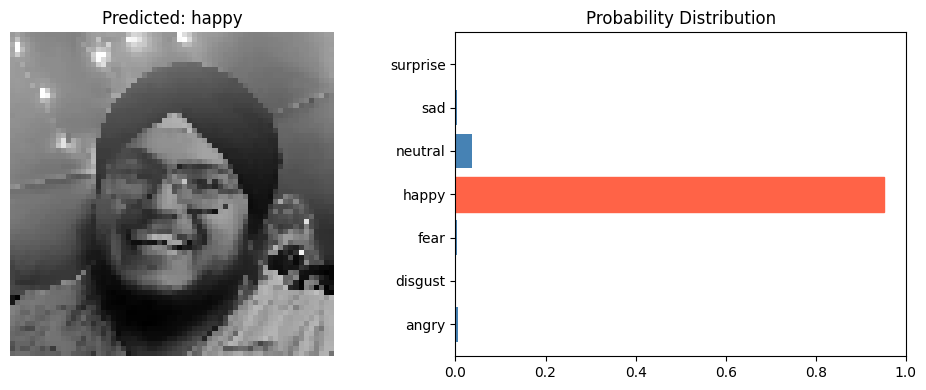

In [11]:
custom_img_path = '/kaggle/input/datasets/sayantanmondal1317/real-life/Harpuneet.jpeg'
raw_img = cv2.imread(custom_img_path, cv2.IMREAD_GRAYSCALE) # load the image in grayscale

if raw_img is None: # measure to prevent code crashing due to improper loading
    print("Error: Could not load the image. Double-check your file path!")
else:
    
    resized_img = cv2.resize(raw_img, (64, 64))
    normalized_img = resized_img / 255.0 # normalize and resize the image
    input_tensor = normalized_img[np.newaxis, ..., np.newaxis]  # format image -> (1, 64, 64, 1) -> one (64, 64, 1) matrix input
    custom_probs = model.predict(input_tensor, verbose=0)[0] # get probabilities and set up plotting grid
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(normalized_img, cmap='gray')  # display the greyscale image, because this is what the model has processed
    axes[0].set_title(f"Predicted: {le.classes_[np.argmax(custom_probs)]}")
    axes[0].axis('off')

    bars = axes[1].barh(le.classes_, custom_probs, color='steelblue')    
    bars[np.argmax(custom_probs)].set_color('tomato')
    axes[1].set_xlim(0, 1)
    axes[1].set_title("Probability Distribution")

    plt.tight_layout()
    plt.show()